# Libraries and functions

In [1]:
import numpy as np

import sys
from pathlib import Path
import os

# path to the directory that CONTAINS the package folder
project_root = Path("/mnt/beegfs/2a/mb12724/franc/theory-language-modeling/")   # adjust to your real path

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from BP.run_global_budget import simulate_bp_lambda_sweep

from BP.run_global_budget import plot_both, plot_hierarchy_observables

/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import matplotlib.pyplot as plt


def load_bp_result(path):
    obj = np.load(path, allow_pickle=True)

    # Case 1: saved with np.save(res): object array containing dict
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()

    # Case 2: saved with np.savez(...)
    if isinstance(obj, np.lib.npyio.NpzFile):
        return {k: obj[k] for k in obj.files}

    raise TypeError(f"Unrecognized file format: {type(obj)}")


def plot_bp_peeled_loss_and_margin_fraction(
    path,
    x_key="lambda_values",
    title_prefix="BP",
    use_log_x=True,
    use_log_y=False,
):
    res = load_bp_result(path)

    print("Available keys:")
    print(res.keys())

    x = np.asarray(res[x_key], dtype=float)
    peeled = np.asarray(res["level_penalty_mean"], dtype=float)
    frac_pos = np.asarray(res["margin_pos_frac"], dtype=float)

    L = peeled.shape[1]

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    for ell in range(L):
        axs[0].plot(x, peeled[:, ell], marker="o", label=fr"$\ell={ell+1}$")

    axs[0].set_xlabel(x_key)
    axs[0].set_ylabel(r"$\langle \log(1+e^{-M_\ell}) \rangle$")
    axs[0].set_title(f"{title_prefix}: peeled test loss")
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(frameon=False)

    for ell in range(L):
        axs[1].plot(x, frac_pos[:, ell], marker="o", label=fr"$\ell={ell+1}$")

    axs[1].set_xlabel(x_key)
    axs[1].set_ylabel(r"$\Pr(M_\ell>0)$")
    axs[1].set_title(f"{title_prefix}: fraction of positive margins")
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(frameon=False)

    if use_log_x:
        pos = x[x > 0]
        if len(pos) == len(x):
            axs[0].set_xscale("log")
            axs[1].set_xscale("log")
        elif len(pos) > 0:
            linthresh = max(float(np.min(pos)) / 2.0, 1e-6)
            axs[0].set_xscale("symlog", linthresh=linthresh)
            axs[1].set_xscale("symlog", linthresh=linthresh)
    if use_log_y:
        axs[0].set_yscale("log")
        axs[1].set_yscale("log")

    fig.tight_layout()
    return fig, axs

# Flat rules

In [21]:
name_save = "bp_global_budget_L4_s2_v64_m4_HIGH"

In [ ]:

os.makedirs("./data/BP", exist_ok=True)

res = simulate_bp_lambda_sweep(
    num_features=32,
    num_classes=32,
    num_synonyms=8,
    tuple_size=2,
    num_layers=3,
    train_size=100,
    test_size=128,
    lambda_values=np.logspace(0., 8.0, 30),
    seed_rules=1,
    seed_sample=1,
)

np.save(f"./data/BP/{name_save}", res, allow_pickle=True)

100%|██████████| 30/30 [39:56<00:00, 79.90s/it] 


In [23]:
res = np.load("./data/BP/"+name_save+".npy", allow_pickle=True).item()

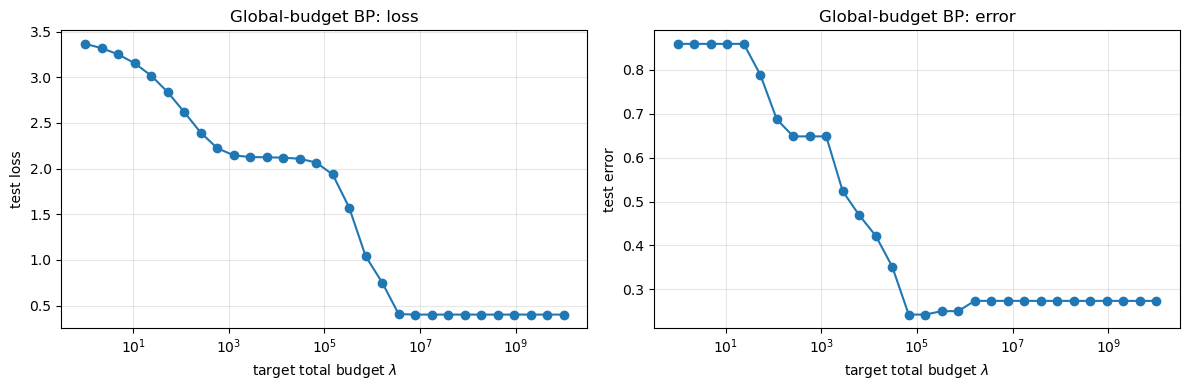

In [18]:
fig, axs = plot_both(res)

Available keys:
dict_keys(['params', 'lambda_values', 'loss_mean', 'loss_std', 'error_mean', 'error_std', 'posterior_norm_mean', 'posterior_norm_std', 'message_total_cost_mean', 'message_total_cost_std', 'message_total_l2_norm_mean', 'message_total_l2_norm_std', 'tau_mean', 'tau_std', 'budget_hit_fraction', 'A_mass_mean', 'B_mass_mean', 'margin_mean', 'margin_pos_frac', 'hier_acc', 'level_penalty_mean', 'residual_mean', 'reconstructed_loss_abs_error_mean', 'raw_per_lambda', 'rules', 'rule_probs', 'train_sequences', 'test_sequences', 'A_masks', 'B_masks', 'note'])


(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Global-budget BP: peeled test loss'}, xlabel='lambda_values', ylabel='$\\langle \\log(1+e^{-M_\\ell}) \\rangle$'>,
        <Axes: title={'center': 'Global-budget BP: fraction of positive margins'}, xlabel='lambda_values', ylabel='$\\Pr(M_\\ell>0)$'>],
       dtype=object))

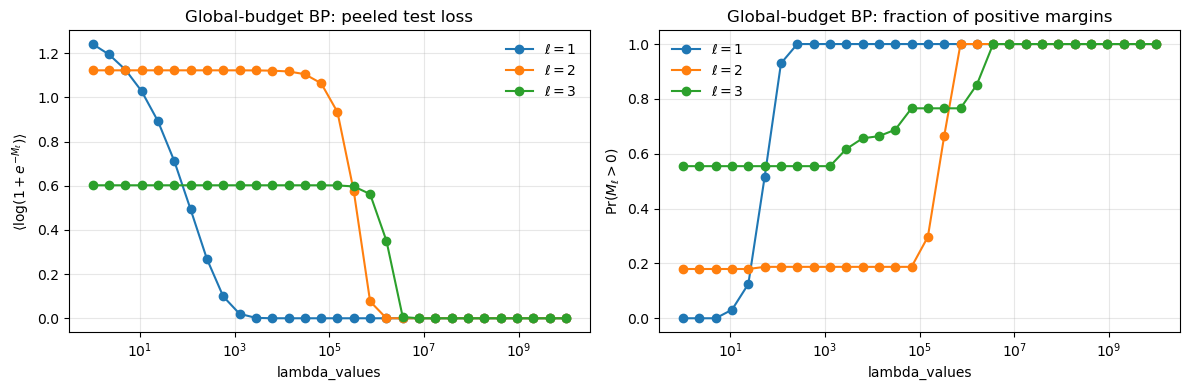

In [19]:
plot_bp_peeled_loss_and_margin_fraction(
    "./data/BP/" + name_save + ".npy",
    x_key="lambda_values",
    title_prefix="Global-budget BP"
)

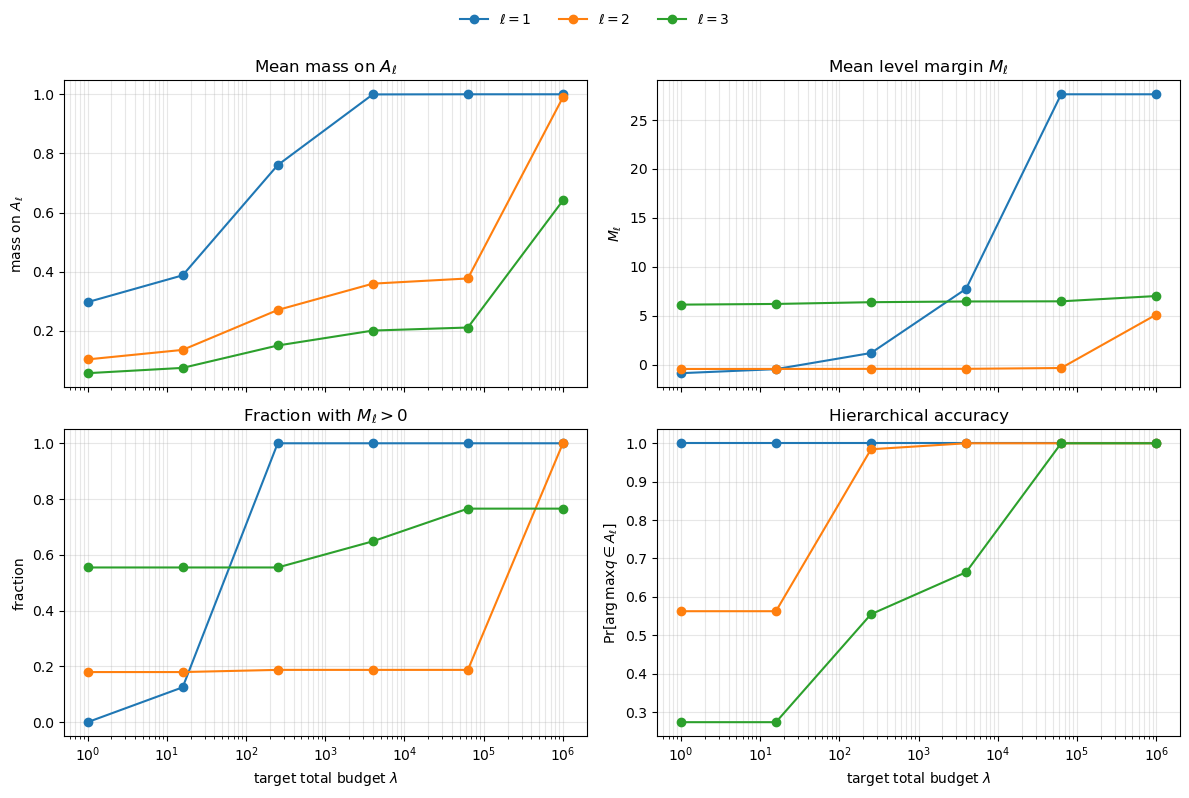

In [7]:
fig2, axs2 = plot_hierarchy_observables(res)

## L=4

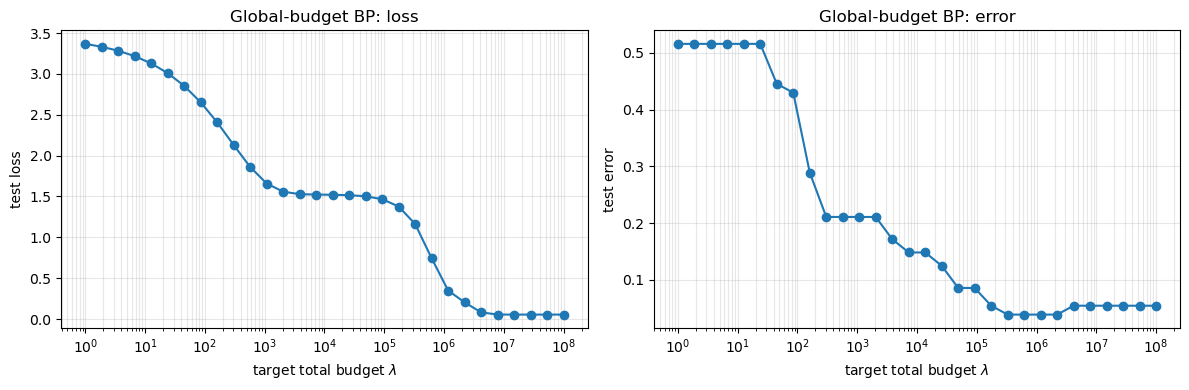

In [28]:
fig, axs = plot_both(res)

Available keys:
dict_keys(['params', 'lambda_values', 'loss_mean', 'loss_std', 'error_mean', 'error_std', 'posterior_norm_mean', 'posterior_norm_std', 'message_total_cost_mean', 'message_total_cost_std', 'message_total_l2_norm_mean', 'message_total_l2_norm_std', 'tau_mean', 'tau_std', 'budget_hit_fraction', 'A_mass_mean', 'B_mass_mean', 'margin_mean', 'margin_pos_frac', 'hier_acc', 'level_penalty_mean', 'residual_mean', 'reconstructed_loss_abs_error_mean', 'raw_per_lambda', 'rules', 'rule_probs', 'train_sequences', 'test_sequences', 'A_masks', 'B_masks', 'note'])


(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Global-budget BP: peeled test loss'}, xlabel='lambda_values', ylabel='$\\langle \\log(1+e^{-M_\\ell}) \\rangle$'>,
        <Axes: title={'center': 'Global-budget BP: fraction of positive margins'}, xlabel='lambda_values', ylabel='$\\Pr(M_\\ell>0)$'>],
       dtype=object))

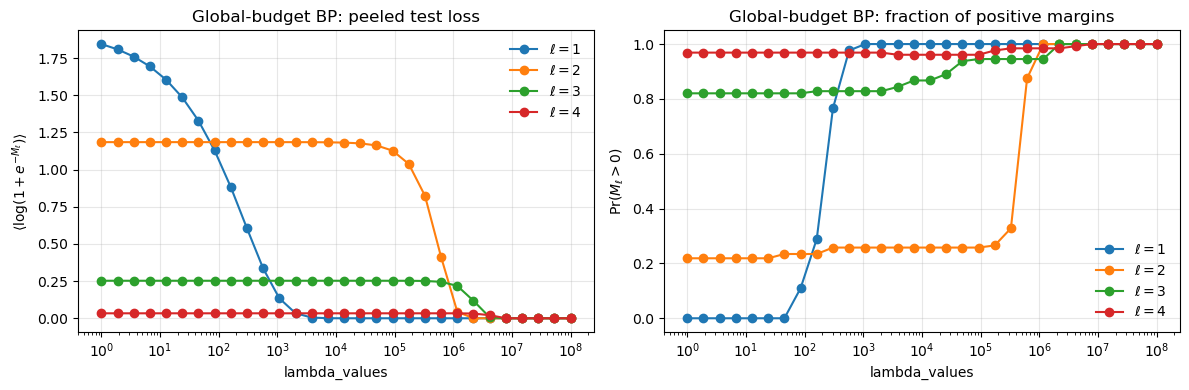

In [29]:
plot_bp_peeled_loss_and_margin_fraction(
    "./data/BP/" + name_save + ".npy",
    x_key="lambda_values",
    title_prefix="Global-budget BP"
)

Available keys:
dict_keys(['params', 'lambda_values', 'loss_mean', 'loss_std', 'error_mean', 'error_std', 'posterior_norm_mean', 'posterior_norm_std', 'message_total_cost_mean', 'message_total_cost_std', 'message_total_l2_norm_mean', 'message_total_l2_norm_std', 'tau_mean', 'tau_std', 'budget_hit_fraction', 'A_mass_mean', 'B_mass_mean', 'margin_mean', 'margin_pos_frac', 'hier_acc', 'level_penalty_mean', 'residual_mean', 'reconstructed_loss_abs_error_mean', 'raw_per_lambda', 'rules', 'rule_probs', 'train_sequences', 'test_sequences', 'A_masks', 'B_masks', 'note'])


(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Global-budget BP: peeled test loss'}, xlabel='lambda_values', ylabel='$\\langle \\log(1+e^{-M_\\ell}) \\rangle$'>,
        <Axes: title={'center': 'Global-budget BP: fraction of positive margins'}, xlabel='lambda_values', ylabel='$\\Pr(M_\\ell>0)$'>],
       dtype=object))

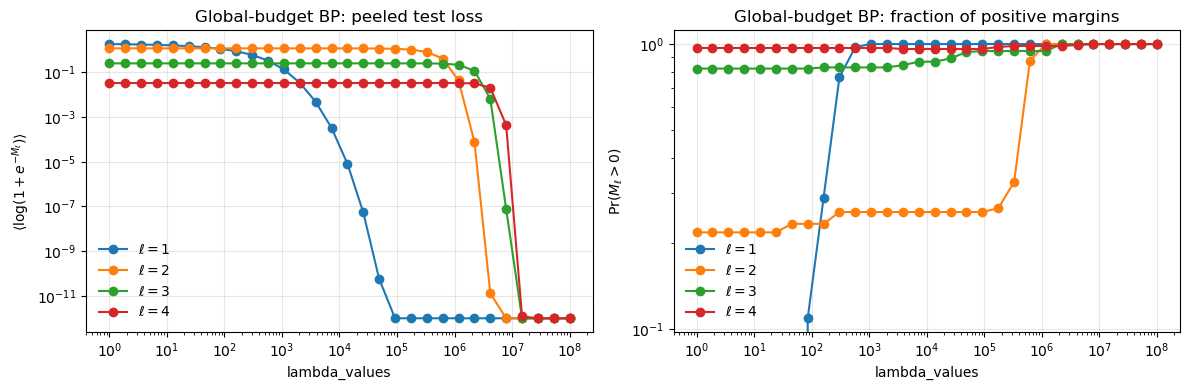

In [31]:
plot_bp_peeled_loss_and_margin_fraction(
    "./data/BP/" + name_save + ".npy",
    x_key="lambda_values",
    title_prefix="Global-budget BP",
    use_log_y=True,
)

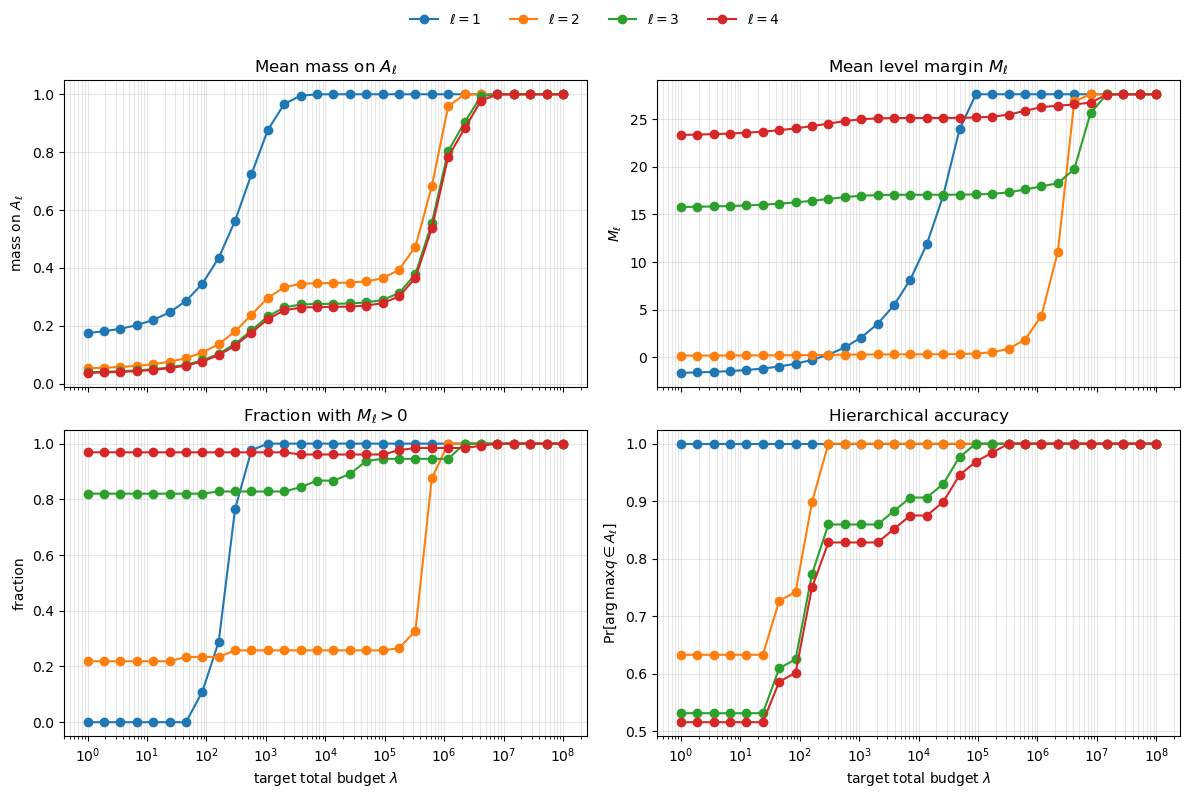

In [30]:
fig2, axs2 = plot_hierarchy_observables(res)

# A=2

In [2]:
name_save = "A2_bp_global_budget_L3_s2_v32_m8"

In [3]:

os.makedirs("./data/BP", exist_ok=True)

res = simulate_bp_lambda_sweep(
    num_features=32,
    num_classes=32,
    num_synonyms=8,
    tuple_size=2,
    num_layers=3,
    train_size=32768,
    test_size=128,
    lambda_values=np.logspace(1., 7.0, 20),
    seed_rules=1,
    seed_sample=1,
    zipf=2,   # exponent is 1+zipf
    layer=1,    # exact repo convention: layer index starts at 1
)

np.save(f"./data/BP/{name_save}", res, allow_pickle=True)

100%|██████████| 20/20 [25:48<00:00, 77.42s/it] 


In [4]:
res = np.load("./data/BP/"+name_save+".npy", allow_pickle=True).item()

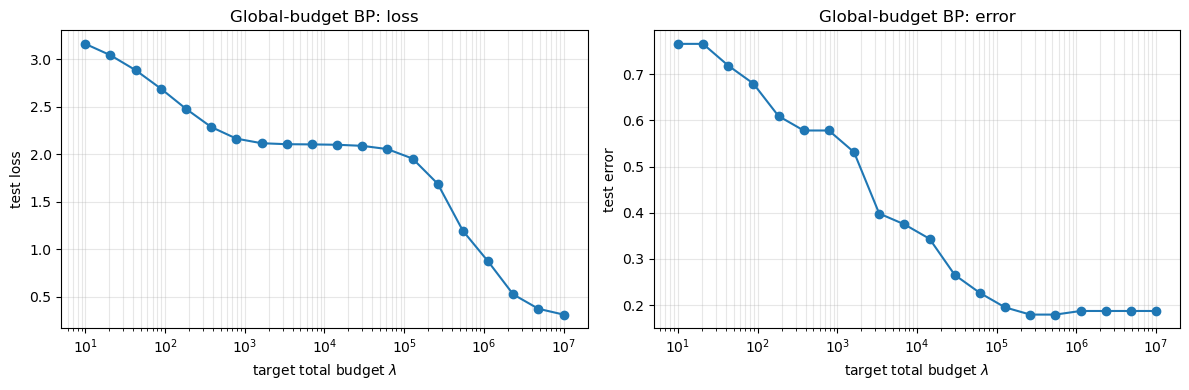

In [5]:
fig, axs = plot_both(res)

In [ ]:
fig2, axs2 = plot_hierarchy_observables(res)